<a href="https://colab.research.google.com/github/HelloPenguin1/Spinal_Metastasis_Classification_TCIA/blob/main/Model_Train_I3DCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy
import sklearn
import torch

print(numpy.__version__)
print(sklearn.__version__)
print(torch.__version__)

2.0.2
1.6.1
2.11.0+cu128


In [2]:
!pip install -q monai SimpleITK nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

from monai.transforms import (
    Compose,
    RandFlip,
    RandRotate,
    RandZoom,
)

import SimpleITK as sitk
import nibabel as nib
from monai.data import set_track_meta

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import os
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, BatchNormalization, Activation, GlobalAveragePooling3D, Dropout, Dense, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [8]:
df = pd.read_csv('/content/labels.csv')

In [9]:
set_track_meta(False)

Loading Dataset Index

In [10]:
df.head()

,filename,label
0,10250_T2.npy,Mixed
1,10352_T11.npy,No Lesion
2,10352_T12.npy,No Lesion
3,10352_L1.npy,No Lesion
4,10352_L2.npy,No Lesion


Extracting Patient ID and Vertebrae Level from the filename

In [11]:
df['Patient_ID'] = df['filename'].apply(lambda x: x.split('_')[0])
df['Vertebra_Level'] = df['filename'].apply(lambda x: x.split('_')[1].replace('.npy', ''))

Loading Data and Split By Patient

In [12]:
df['label']

,label
0,Mixed
1,No Lesion
2,No Lesion
3,No Lesion
4,No Lesion
...,...
284,Lytic
285,Lytic
286,Lytic
287,Lytic


Label Mapping

In [13]:
#Label Mapping
label_mapping = {'No Lesion': 0, 'Lytic': 1, 'Blastic': 2, 'Mixed': 3}
df['label_int'] = df['label'].map(label_mapping)


In [14]:
TENSOR_DIR = "drive/MyDrive/TCIA_Original/tensors"

3D Augmentation



In [15]:
train_transforms = Compose([
    # 1. Left/Right Flip
    RandFlip(prob=0.5, spatial_axis=2),

    # 2. Subtle Rotations
    RandRotate(range_x=0.17, range_y=0.17, range_z=0.17, prob=0.5),

    # 3. Subtle Zooming
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])

Helper Functions

In [16]:
def parse_npy_with_monai(filename, label, is_training):
    filepath = os.path.join(TENSOR_DIR, filename.decode('utf-8'))
    tensor = np.load(filepath).astype(np.float32)

    if is_training:
        tensor = np.expand_dims(tensor, axis=0)
        tensor = train_transforms(tensor)
        tensor = np.asarray(tensor)
        tensor = np.moveaxis(tensor, 0, -1)
    else:
        tensor = np.expand_dims(tensor, axis=-1)

    return tensor, label





def tf_load_train(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda f, l: parse_npy_with_monai(f, l, is_training=True),
        inp=[filename, label], Tout=[tf.float32, tf.int32]
    )
    tensor.set_shape((64, 64, 64, 1))
    label.set_shape(())
    return tensor, label

def tf_load_val(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda filename, label: parse_npy_with_monai(filename, label, is_training=False),
        inp=[filename, label],
        Tout=[tf.float32, tf.int32]
    )
    tensor.set_shape((64, 64, 64, 1))
    label.set_shape(())
    return tensor, tf.cast(label, tf.int32)

In [17]:
def create_dataset(dataframe, batch_size=8, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filename'].values, dataframe['label_int'].values))

    if is_training:
        ds = ds.shuffle(buffer_size=len(dataframe))
        ds = ds.map(tf_load_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(tf_load_val, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [42]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Define strict Callbacks

training_callbacks = [
    EarlyStopping(
        monitor='val_accuracy', #changed to val accuracy
        mode='max',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

Model Definition

In [20]:
def inception_3d_block(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, fpool):
    # Path 1: 1x1x1 Convolution (Extracts basic features)
    path1 = Conv3D(f1x1, (1, 1, 1), padding='same')(x)
    path1 = BatchNormalization()(path1)
    path1 = Activation('relu')(path1)

    # Path 2: 1x1x1 → 3x3x3 Convolution (Captures mid-range features)
    path2 = Conv3D(f3x3_reduce, (1, 1, 1), padding='same')(x)
    path2 = Activation('relu')(path2)

    path2 = Conv3D(f3x3, (3, 3, 3), padding='same')(path2)
    path2 = Activation('relu')(path2)

    # Path 3: 1x1x1 → 5x5x5 Convolution (Captures larger features)
    path3 = Conv3D(f5x5_reduce, (1, 1, 1), padding='same')(x)
    path3 = Activation('relu')(path3)

    path3 = Conv3D(f5x5, (5, 5, 5), padding='same')(path3)
    path3 = Activation('relu')(path3)

    # Path 4: 3x3x3 Max Pool → 1x1x1 Convolution (Captures background information)
    path4 = MaxPooling3D((3, 3, 3), strides=(1, 1, 1), padding='same')(x)
    path4 = Conv3D(fpool, (1, 1, 1), padding='same')(path4)
    path4 = Activation('relu')(path4)

    # Final Step: Concatenate all paths
    return concatenate([path1, path2, path3, path4], axis=-1)

Model Training

In [ ]:
def SimpleI3DNet2(input_shape=(64, 64, 64, 1), num_classes=4):
    """"Added label smoothening and converted labels to one-hot encoded"""

    inputs = Input(shape=input_shape)

    # Initial 3D Convolution & Pooling
    x = Conv3D(64, (7, 7, 7), strides=(2, 2, 2), padding='same')(inputs)
    x = Activation('relu')(x)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # First I3D Inception Block
    x = inception_3d_block(x, 64, 96, 128, 16, 32, 32)

    # Second I3D Inception Block
    x = inception_3d_block(x, 128, 128, 192, 32, 96, 64)

    # Pooling layer
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # Third I3D Inception Block
    x = inception_3d_block(x, 192, 96, 208, 16, 48, 64)

    # Global Average Pooling
    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.5)(x)

    # Fully connected layer for classification
    x = Dense(num_classes, activation='softmax')(x)

    # Define the model
    model = Model(inputs=inputs, outputs=x)

    # UPDATED: Switched back to sparse_categorical_crossentropy to prevent one-hot VRAM crashes
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss=CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'],
                  )

    return model

In [21]:
K_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_metrics = []
oof_true_labels = []
oof_predictions = []

In [ ]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"\n               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")

    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    # Explicitly cast label_int to np.int32 to match tf.numpy_function's Tout declaration
    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    train_ds = create_dataset(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset(val_df, batch_size=8, is_training=False)

    # Helper function to convert integer labels to one-hot for CategoricalCrossentropy
    def convert_to_one_hot_labels(image, label_int_scalar):
        num_classes = 4  # Assuming 4 classes as per SimpleI3DNet2
        return image, tf.one_hot(tf.cast(label_int_scalar, tf.int32), depth=num_classes)

    # Apply the conversion to the datasets
    train_ds = train_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)

    # 3. Build a new model and prevent weight leaks
    tf.keras.backend.clear_session()

    model = SimpleI3DNet2()


    # 5. Model train
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        class_weight=class_weights_dict,
        callbacks=training_callbacks, # Injected Callbacks
        verbose=1
    )

    # 6. Final validation accuracy
    # IMPORTANT: Because EarlyStopping restores the BEST weights, looking at the last epoch of `history`
    # is inaccurate. We must run a quick evaluate() to get the true restored performance.
    val_loss, final_val_acc = model.evaluate(val_ds, verbose=0)
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Best Restored Validation Accuracy: {final_val_acc:.4f}")

    # 7. CAPTURE OUT-OF-FOLD (OOF) PREDICTIONS
    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        # labels are currently one-hot arrays (e.g. [0, 0, 1, 0]).
        # Convert back to integers (e.g. 2) for the final Confusion Matrix and Classification Report
        true_classes = np.argmax(labels.numpy(), axis=-1)
        oof_true_labels.extend(true_classes)

        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)


               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.3621 - loss: 1.6036 - val_accuracy: 0.0652 - val_loss: 2.1702 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.4650 - loss: 1.3108 - val_accuracy: 0.1304 - val_loss: 1.7331 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - accuracy: 0.5103 - loss: 1.2445 - val_accuracy: 0.5000 - val_loss: 1.2910 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - accuracy: 0.5350 - loss: 1.1524 - val_accuracy: 0.1304 - val_loss: 1.4165 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - accuracy: 0.5103 - loss: 1.1684 - val_accuracy: 0.1304 - val_loss: 1.6018 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.5391 - loss: 1.1309 - val_accuracy: 0.1522 - val_loss: 1.4401 - learning_rate: 


               FOLD 5
Training on 42 patients (239 volumes)
Testing on 10 patients (50 volumes)
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 46s 956ms/step - accuracy: 0.3556 - loss: 1.6638 - val_accuracy: 0.2200 - val_loss: 1.5228 - learning_rate: 0.0010
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.4100 - loss: 1.3693 - val_accuracy: 0.4200 - val_loss: 1.3729 - learning_rate: 0.0010
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.4351 - loss: 1.2129 - val_accuracy: 0.4200 - val_loss: 1.4273 - learning_rate: 0.0010
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.4644 - loss: 1.2060 - val_accuracy: 0.7200 - val_loss: 1.1574 - learning_rate: 0.0010
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5907 - loss: 1.0270
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 205ms/step - accuracy: 0.5356 - loss: 1.1799 - val_accuracy: 0.5400 - val_loss: 1.2526 - learning_rat

In [ ]:
fold_metrics

[0.5,
 0.7790697813034058,
 0.13636364042758942,
 0.3333333432674408,
 0.2199999988079071]

In [ ]:
sum(fold_metrics)/5

0.3937533527612686

Instable validation accuracy

In [22]:
def SimpleI3DNet3(input_shape=(64, 64, 64, 1), num_classes=4):
    """"Added label smoothening and converted labels to one-hot encoded"""

    inputs = Input(shape=input_shape)

    # Initial 3D Convolution & Pooling
    x = Conv3D(64, (7, 7, 7), strides=(2, 2, 2), padding='same')(inputs)
    x = Activation('relu')(x)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # First I3D Inception Block
    x = inception_3d_block(x, 64, 96, 128, 16, 32, 32)

    # Second I3D Inception Block
    x = inception_3d_block(x, 128, 128, 192, 32, 96, 64)

    # Pooling layer
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # Third I3D Inception Block
    x = inception_3d_block(x, 192, 96, 208, 16, 48, 64)

    # Global Average Pooling
    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.5)(x)

    # Fully connected layer for classification
    x = Dense(num_classes, activation='softmax')(x)

    # Define the model
    model = Model(inputs=inputs, outputs=x)

    # UPDATED: Switched back to sparse_categorical_crossentropy to prevent one-hot VRAM crashes
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss=CategoricalCrossentropy(label_smoothing=0.1),
                  metrics=['accuracy'],
                  )

    return model

In [ ]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"\n               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")

    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    train_ds = create_dataset(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset(val_df, batch_size=8, is_training=False)

    def convert_to_one_hot_labels(image, label_int_scalar):
        num_classes = 4  # Assuming 4 classes as per SimpleI3DNet2
        return image, tf.one_hot(tf.cast(label_int_scalar, tf.int32), depth=num_classes)

    train_ds = train_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)

    tf.keras.backend.clear_session()

    model = SimpleI3DNet3()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        class_weight=class_weights_dict,
        callbacks=training_callbacks,
        verbose=1
    )


    val_loss, final_val_acc = model.evaluate(val_ds, verbose=0)
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Best Restored Validation Accuracy: {final_val_acc:.4f}")

    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        true_classes = np.argmax(labels.numpy(), axis=-1)
        oof_true_labels.extend(true_classes)

        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)


               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 43s 839ms/step - accuracy: 0.3663 - loss: 1.4324 - val_accuracy: 0.1304 - val_loss: 1.4186 - learning_rate: 1.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - accuracy: 0.4280 - loss: 1.2736 - val_accuracy: 0.1304 - val_loss: 1.4072 - learning_rate: 1.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 171ms/step - accuracy: 0.4033 - loss: 1.2901 - val_accuracy: 0.1304 - val_loss: 1.3574 - learning_rate: 1.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 200ms/step - accuracy: 0.5391 - loss: 1.2480 - val_accuracy: 0.1304 - val_loss: 1.3595 - learning_rate: 1.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 175ms/step - accuracy: 0.5350 - loss: 1.1655 - val_accuracy: 0.1522 - val_loss: 1.3850 - learning_rate: 1.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.5267 - loss: 1.1853 - val_accuracy: 0.1304 - val_loss: 1

In [ ]:
fold_metrics[-5:]

[0.1304347813129425,
 0.6279069781303406,
 0.13636364042758942,
 0.2698412835597992,
 0.3400000035762787]

In [ ]:
sum(fold_metrics[-5:])/5

0.3009093374013901

Try three

Implementing Micro 3d cnn

In [23]:
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, BatchNormalization, Activation, GlobalAveragePooling3D, Dropout, Dense, concatenate, SpatialDropout3D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

def micro_inception_3d_block(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, fpool):
    # Added he_normal initialization to ALL convolutional layers to prevent dead gradients
    init = 'he_normal'

    # Path 1: 1x1x1 Convolution
    path1 = Conv3D(f1x1, (1, 1, 1), padding='same', kernel_initializer=init)(x)
    path1 = BatchNormalization()(path1)
    path1 = Activation('relu')(path1)

    # Path 2: 1x1x1 → 3x3x3
    path2 = Conv3D(f3x3_reduce, (1, 1, 1), padding='same', kernel_initializer=init)(x)
    path2 = Activation('relu')(path2)
    path2 = Conv3D(f3x3, (3, 3, 3), padding='same', kernel_initializer=init)(path2)
    path2 = Activation('relu')(path2)

    # Path 3: 1x1x1 → 5x5x5
    path3 = Conv3D(f5x5_reduce, (1, 1, 1), padding='same', kernel_initializer=init)(x)
    path3 = Activation('relu')(path3)
    path3 = Conv3D(f5x5, (5, 5, 5), padding='same', kernel_initializer=init)(path3)
    path3 = Activation('relu')(path3)

    # Path 4: 3x3x3 Max Pool → 1x1x1
    path4 = MaxPooling3D((3, 3, 3), strides=(1, 1, 1), padding='same')(x)
    path4 = Conv3D(fpool, (1, 1, 1), padding='same', kernel_initializer=init)(path4)
    path4 = Activation('relu')(path4)

    return concatenate([path1, path2, path3, path4], axis=-1)

def MicroI3DNet(input_shape=(64, 64, 64, 1), num_classes=4):
    inputs = Input(shape=input_shape)
    init = 'he_normal'

    # Initial 3D Convolution & Pooling (Filters reduced from 64 to 32)
    x = Conv3D(32, (7, 7, 7), strides=(2, 2, 2), padding='same', kernel_initializer=init)(inputs)
    x = Activation('relu')(x)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # First I3D Block (Filters slashed aggressively)
    x = micro_inception_3d_block(x, 32, 48, 64, 8, 16, 16)

    # Second I3D Block
    x = micro_inception_3d_block(x, 64, 64, 96, 16, 48, 32)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    # Third I3D Block
    x = micro_inception_3d_block(x, 96, 48, 104, 8, 24, 32)

    # Advanced Regularization Head
    x = SpatialDropout3D(0.4)(x) # Destroys 3D channel memorization
    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.5)(x)          # Standard dense dropout

    x = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=x)

    # Bump LR slightly back up to 5e-4 to give it momentum to escape local minima
    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model

In [24]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"\n               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")

    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    train_ds = create_dataset(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset(val_df, batch_size=8, is_training=False)

    def convert_to_one_hot_labels(image, label_int_scalar):
        num_classes = 4  # Assuming 4 classes as per SimpleI3DNet2
        return image, tf.one_hot(tf.cast(label_int_scalar, tf.int32), depth=num_classes)

    train_ds = train_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_ds.map(convert_to_one_hot_labels, num_parallel_calls=tf.data.AUTOTUNE)

    tf.keras.backend.clear_session()

    model = MicroI3DNet()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        class_weight=class_weights_dict,
        callbacks=training_callbacks,
        verbose=1
    )


    val_loss, final_val_acc = model.evaluate(val_ds, verbose=0)
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Best Restored Validation Accuracy: {final_val_acc:.4f}")

    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        true_classes = np.argmax(labels.numpy(), axis=-1)
        oof_true_labels.extend(true_classes)

        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)


               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.3169 - loss: 1.6704 - val_accuracy: 0.0652 - val_loss: 1.7944 - learning_rate: 5.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 166ms/step - accuracy: 0.3704 - loss: 1.4127 - val_accuracy: 0.1304 - val_loss: 1.4196 - learning_rate: 5.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.4033 - loss: 1.3649 - val_accuracy: 0.1304 - val_loss: 1.4267 - learning_rate: 5.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.4815 - loss: 1.3105 - val_accuracy: 0.2609 - val_loss: 1.5566 - learning_rate: 5.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.4609 - loss: 1.2844 - val_accuracy: 0.1522 - val_loss: 1.3998 - learning_rate: 5.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 134ms/step - accuracy: 0.4650 - loss: 1.2685 - val_accuracy: 0.1522 - val_loss: 1.5


               FOLD 5
Training on 42 patients (239 volumes)
Testing on 10 patients (50 volumes)
Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 720ms/step - accuracy: 0.2762 - loss: 2.0064 - val_accuracy: 0.2200 - val_loss: 1.5831 - learning_rate: 5.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 179ms/step - accuracy: 0.3054 - loss: 1.4874 - val_accuracy: 0.2200 - val_loss: 1.4780 - learning_rate: 5.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.3556 - loss: 1.4328 - val_accuracy: 0.2200 - val_loss: 1.3945 - learning_rate: 5.0000e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 169ms/step - accuracy: 0.4477 - loss: 1.3756 - val_accuracy: 0.4800 - val_loss: 1.2376 - learning_rate: 5.0000e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.4351 - loss: 1.3384 - val_accuracy: 0.3000 - val_loss: 1.3232 - learning_rate: 5.0000e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - accuracy: 0.4059 - loss: 1.3205 - val_accuracy: 0.3600 - val_loss: 1

In [26]:
fold_metrics

[0.41304346919059753,
 0.569767415523529,
 0.13636364042758942,
 0.095238097012043,
 0.2199999988079071]

In [28]:
sum(fold_metrics)/5

0.28688252419233323

Test 3, falling back on the original architeture....

### Reusable function

In [43]:
def run_kfold_training(df, model_builder_fn, create_dataset_fn, n_splits=5, epochs=50, batch_size=8):
    """
    Executes a Stratified Group K-Fold cross-validation training loop.

    Args:
        df: Pandas DataFrame containing 'filename', 'label_int', and 'Patient_ID'.
        model_builder_fn: A function that returns a compiled Keras model.
        create_dataset_fn: Function to generate tf.data.Datasets.
        n_splits: Number of folds (default 5).
        epochs: Maximum number of epochs per fold (default 50).
        batch_size: Batch size for training/validation (default 8).

    Returns:
        fold_metrics: List of final validation accuracies per fold.
        oof_true_labels: Aggregated true labels for the entire dataset.
        oof_predictions: Aggregated model predictions for the entire dataset.
    """
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_metrics = []
    oof_true_labels = []
    oof_predictions = []

    def convert_to_one_hot(image, label_int_scalar):
        return image, tf.one_hot(tf.cast(label_int_scalar, tf.int32), depth=4)

    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
        print(f"                 FOLD {fold + 1}")
        train_df = df.iloc[train_idx].copy()
        val_df = df.iloc[val_idx].copy()

        print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
        print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")

        train_df['label_int'] = train_df['label_int'].astype(np.int32)
        val_df['label_int'] = val_df['label_int'].astype(np.int32)
        #weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
        #class_weights_dict = {i: weight for i, weight in enumerate(weights)}

        train_ds = create_dataset_fn(train_df, batch_size=batch_size, is_training=True)
        val_ds = create_dataset_fn(val_df, batch_size=batch_size, is_training=False)

        train_ds = train_ds.map(convert_to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
        val_ds = val_ds.map(convert_to_one_hot, num_parallel_calls=tf.data.AUTOTUNE)

        tf.keras.backend.clear_session()

        model = model_builder_fn()

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=1)
        ]

        model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=epochs,
            #class_weight=class_weights_dict,
            callbacks=callbacks,
            verbose=1
        )

        val_loss, final_val_acc = model.evaluate(val_ds, verbose=0)
        fold_metrics.append(final_val_acc)
        print(f"\n>>> Fold {fold + 1} Best Restored Validation Accuracy: {final_val_acc:.4f} <<<\n")

        print(f"Gathering predictions for Fold {fold + 1} validation patients...")
        for images, labels in val_ds:
            true_classes = np.argmax(labels.numpy(), axis=-1)
            oof_true_labels.extend(true_classes)

            preds = model.predict(images, verbose=0)
            oof_predictions.extend(preds)

    return fold_metrics, oof_true_labels, oof_predictions

In [44]:
from tensorflow.keras.losses import CategoricalFocalCrossentropy

In [45]:
def SimpleI3DNet_Focal(input_shape=(64, 64, 64, 1), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv3D(64, (7, 7, 7), strides=(2, 2, 2), padding='same')(inputs)
    x = Activation('relu')(x)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    x = inception_3d_block(x, 64, 96, 128, 16, 32, 32)
    x = inception_3d_block(x, 128, 128, 192, 32, 96, 64)
    x = MaxPooling3D((3, 3, 3), strides=(2, 2, 2), padding='same')(x)

    x = inception_3d_block(x, 192, 96, 208, 16, 48, 64)

    x = GlobalAveragePooling3D()(x)
    x = Dropout(0.5)(x)

    x = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=x)

    # 3. THE CRITICAL COMPILATION FIX
    model.compile(
        optimizer=Adam(learning_rate=3e-4), # The 3e-4 sweet spot
        # gamma=2.0 aggressively punishes the model for guessing the majority class
        loss=CategoricalFocalCrossentropy(gamma=2.0),
        metrics=['accuracy']
    )

    return model

run model

In [32]:
metrics, true_labels, predictions = run_kfold_training(
    df=df,
    model_builder_fn=SimpleI3DNet_Focal,
    create_dataset_fn=create_dataset,
    n_splits=5
)

                 FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 58s 972ms/step - accuracy: 0.3498 - loss: 0.2342 - val_accuracy: 0.1522 - val_loss: 0.1959 - learning_rate: 3.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.4321 - loss: 0.1684 - val_accuracy: 0.1304 - val_loss: 0.2053 - learning_rate: 3.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 178ms/step - accuracy: 0.4774 - loss: 0.1535 - val_accuracy: 0.1304 - val_loss: 0.1817 - learning_rate: 3.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.5514 - loss: 0.1363 - val_accuracy: 0.1304 - val_loss: 0.1866 - learning_rate: 3.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step - accuracy: 0.5103 - loss: 0.1405 - val_accuracy: 0.1304 - val_loss: 0.1986 - learning_rate: 3.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.5473 - loss: 0.1311 - val_accuracy: 0.0870 - val_loss: 

In [35]:
sum(metrics)/5

0.48842221349477766

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [39]:
def generate_clinical_metrics(oof_true_labels, oof_predictions, class_names=None):
    """
    Generates a Classification Report, Confusion Matrix, and Multi-Class ROC Curve
    for Out-Of-Fold (OOF) medical imaging predictions.
    """
    if class_names is None:
        class_names = ['No Lesion', 'Lytic', 'Blastic', 'Mixed']

    # 1. Convert lists to numpy arrays for Scikit-Learn
    y_true = np.array(oof_true_labels)
    y_pred_probs = np.array(oof_predictions) # Shape should be (N_samples, 4)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # ==========================================
    # 1. CLASSIFICATION REPORT (Focus on Macro F1)
    # ==========================================
    print("======================================================")
    print("FINAL OUT-OF-FOLD CLASSIFICATION REPORT")
    print("======================================================")
    print(classification_report(y_true, y_pred_classes, target_names=class_names, digits=4))

    # ==========================================
    # 2. CONFUSION MATRIX
    # ==========================================
    cm = confusion_matrix(y_true, y_pred_classes)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    plt.title('Out-Of-Fold Confusion Matrix (All Folds Combined)', fontsize=16)
    plt.ylabel('True Ground-Truth Label', fontsize=14)
    plt.xlabel('I3D Model Prediction', fontsize=14)
    plt.tight_layout()
    plt.show()

    # ==========================================
    # 3. MULTI-CLASS ROC & AUC CURVES (One-vs-Rest)
    # ==========================================
    # Binarize the true labels for multi-class ROC calculation
    n_classes = len(class_names)
    y_true_binarized = label_binarize(y_true, classes=[0, 1, 2, 3])

    plt.figure(figsize=(10, 8))

    colors = ['green', 'red', 'blue', 'purple']

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=colors[i], lw=2,
                 label=f'ROC curve for {class_names[i]} (AUC = {roc_auc:.3f})')

    # Plot the random chance diagonal line
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Chance (AUC = 0.500)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title('Multi-Class ROC Curves (One-vs-Rest)', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

FINAL OUT-OF-FOLD CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Lesion     0.5702    0.5603    0.5652       116
       Lytic     0.1739    0.2857    0.2162        42
     Blastic     0.3824    0.2364    0.2921        55
       Mixed     0.8056    0.7632    0.7838        76

    accuracy                         0.5121       289
   macro avg     0.4830    0.4614    0.4643       289
weighted avg     0.5387    0.5121    0.5200       289



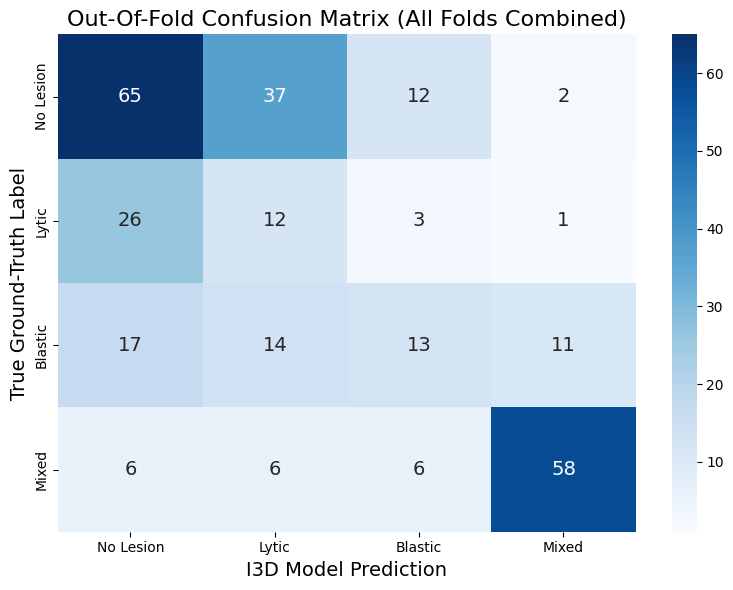

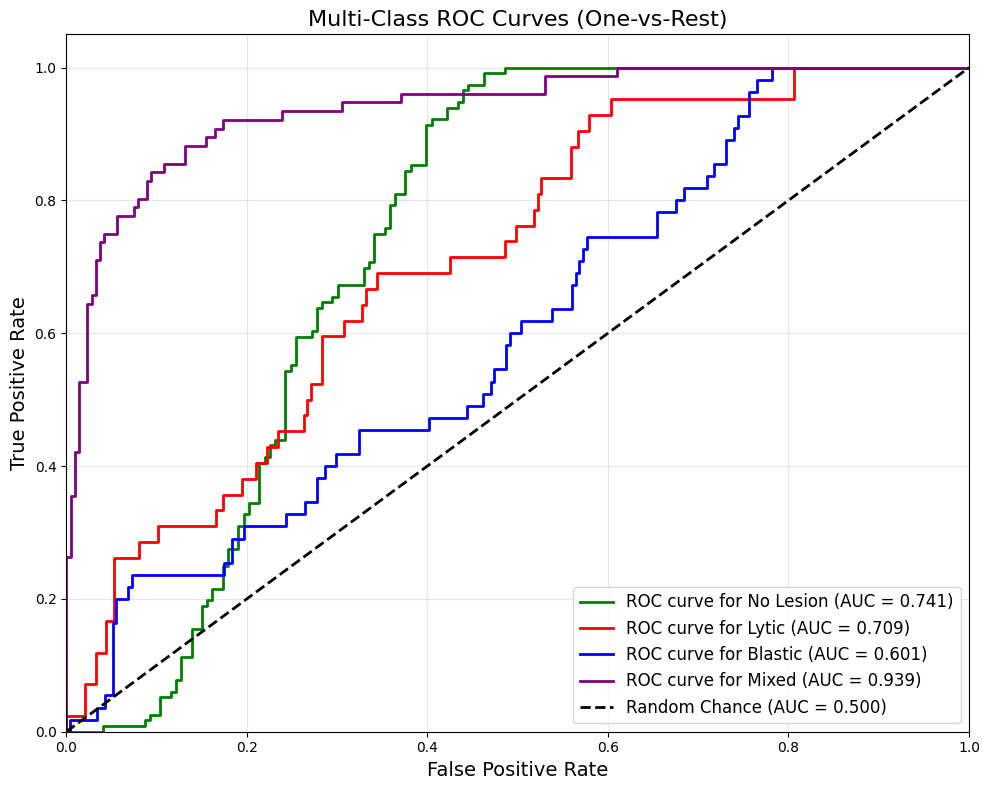

In [40]:
generate_clinical_metrics(true_labels, predictions)

Next change: remove class weights, let focalcrossentropy handle the balancing, chnage metric to track max val accuracy

I went back and changed the functions itself, callback change and commented the class weights

In [ ]:
metrics2, true_labels2, predictions2 = run_kfold_training(
    df=df,
    model_builder_fn=SimpleI3DNet_Focal,
    create_dataset_fn=create_dataset,
    n_splits=5
)

                 FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 47s 842ms/step - accuracy: 0.4609 - loss: 0.2133 - val_accuracy: 0.0870 - val_loss: 0.2290 - learning_rate: 3.0000e-04
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.4856 - loss: 0.1620 - val_accuracy: 0.5000 - val_loss: 0.1737 - learning_rate: 3.0000e-04
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 233ms/step - accuracy: 0.5638 - loss: 0.1456 - val_accuracy: 0.5217 - val_loss: 0.1686 - learning_rate: 3.0000e-04
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step - accuracy: 0.5679 - loss: 0.1389 - val_accuracy: 0.2174 - val_loss: 0.1880 - learning_rate: 3.0000e-04
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 220ms/step - accuracy: 0.5556 - loss: 0.1384 - val_accuracy: 0.5217 - val_loss: 0.1809 - learning_rate: 3.0000e-04
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.6049 - loss: 0.1144 - val_accuracy: 0.5435 - val_loss: 